# Notebook: XGBoost


In [ ]:
import sys

from pathlib import Path
from time import perf_counter
from zipfile import ZipFile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import  train_test_split
from sklearn.preprocessing import FunctionTransformer,  OrdinalEncoder

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))



In [3]:
RANDOM_STATE = 5


In [4]:
with ZipFile("archive (10).zip", mode="r") as project_data:
    with project_data.open("hospital_deterioration_hourly_panel.csv", mode="r") as f:
        deterioration_hourly_panel = pd.read_csv(f)
    with project_data.open("hospital_deterioration_ml_ready.csv", mode="r") as f:
        deterioration_ml_ready = pd.read_csv(f)
    with project_data.open("labs_timeseries.csv", mode="r") as f:
        labs_timeseries = pd.read_csv(f)
    with project_data.open("patients.csv", mode="r") as f:
        patients = pd.read_csv(f)
    with project_data.open("vitals_timeseries.csv", mode="r") as f:
        vitals_timeseries = pd.read_csv(f)


datasets = [
    deterioration_hourly_panel,
    labs_timeseries,
    patients,
    vitals_timeseries,
]


In [5]:
def get_merged_data_w_ids(datasets_, join_cols=['patient_id', 'hour_from_admission'], how='left', strict=True, return_report=False):

    datasets = [(f'df_{i}', df) for i, df in enumerate(datasets_)]

    cleaned = []
    for name, df in datasets:
        usable = [c for c in join_cols if c in df.columns]
        cleaned.append((str(name), df, usable))

    # Start from the dataset with the most available join columns (then most rows).
    cleaned.sort(key=lambda x: (len(x[2]), x[1].shape[0]), reverse=True)
    base_name, merged, base_join_cols = cleaned[0]
    merged = merged.copy()

    for name, df, _ in cleaned[1:]:
        common_cols = [c for c in join_cols if c in merged.columns and c in df.columns]

        # Keep only join keys and columns not yet present in the merged base.
        cols_to_merge = [col for col in df.columns if (col not in merged.columns) or (col in common_cols)]
        dropped_duplicates = [col for col in df.columns if col not in cols_to_merge]
        df_to_merge = df[cols_to_merge].copy()

        left_unique = not merged.duplicated(subset=common_cols).any()
        right_unique = not df_to_merge.duplicated(subset=common_cols).any()
        if left_unique and right_unique:
            relationship = 'one_to_one'
        elif left_unique and not right_unique:
            relationship = 'one_to_many'
        elif not left_unique and right_unique:
            relationship = 'many_to_one'
        else:
            relationship = 'many_to_many'
        
        merged = merged.merge(
            df_to_merge,
            on=common_cols,
            how=how,
            validate=relationship,
            suffixes=('', f'_{name}')
        )

    return merged

joined_data = get_merged_data_w_ids(
    datasets_=datasets,
    join_cols=["patient_id", "hour_from_admission"],
    how="left",
    strict=True,
    return_report=True,
)


In [6]:

filtered_data = joined_data.loc[
    (joined_data["hour_from_admission"] < joined_data["deterioration_hour"])
    | (joined_data["deterioration_hour"] == -1)
].copy()
filtered_data = filtered_data[deterioration_ml_ready.columns].copy()


In [7]:

print("Unfiltered shape:", deterioration_ml_ready.shape)
print("Class counts (unfiltered):")
print(deterioration_ml_ready["deterioration_next_12h"].value_counts())
print("Filtered shape:", filtered_data.shape)
print("Class counts (filtered):")
print(filtered_data["deterioration_next_12h"].value_counts())


Unfiltered shape: (417866, 22)
Class counts (unfiltered):
deterioration_next_12h
0    395277
1     22589
Name: count, dtype: int64
Filtered shape: (382548, 22)
Class counts (filtered):
deterioration_next_12h
0    359959
1     22589
Name: count, dtype: int64


In [8]:

#--------------------------------------------------------------------------------------
# target(s), feature(s), numeric and or categoric column(s)
target_col = "deterioration_next_12h"
feature_cols = [c for c in filtered_data.columns if c != target_col]
num_cols, cat_cols = [ c for c in filtered_data.select_dtypes('number').columns if c != target_col], filtered_data.select_dtypes('object').columns

#--------------------------------------------------------------------------------------
# PRE DETERIORATION
X_population = filtered_data[feature_cols].copy()
y_population = filtered_data[target_col].astype(int).copy()

#--------------------------------------------------------------------------------------
# PRE & POST DETERIORATION
X_post_deterioration = deterioration_ml_ready[feature_cols].copy()
y_post_deterioration = deterioration_ml_ready[target_col].astype(int).copy()

#--------------------------------------------------------------------------------------
# SCALE NUMERIC
# According to HospitalClinicalDeterioration/DistributionAnalysis.ipynb, the biggest issue with the data appears to be outliers, 
# tests in HospitalClinicalDeterioration/HCD_xgboost_preprocess_benchmark.ipynb.ipynb 
# reveal that custom transformer: x / (1 + abs(x)) consitently performed on par with other transformers
# moreover, it often did so without cliped outliers
numeric_transformer = FunctionTransformer(
        lambda x: x / (1.0 + np.abs(x)),
        validate=False,
    )


X_population_num_scaled = numeric_transformer.fit_transform(X_population[num_cols])
if hasattr(X_population_num_scaled,'toarray'):
    X_population_num_scaled = X_population_num_scaled.toarray()
X_post_det_num_scaled = numeric_transformer.transform(X_post_deterioration[num_cols])
if hasattr(X_post_det_num_scaled,'toarray'):
    X_post_det_num_scaled = X_post_det_num_scaled.toarray()

original_columns, new_columns = list(numeric_transformer.feature_names_in_), num_cols
X_population = X_population.drop(columns=original_columns)
X_population[new_columns] = X_population_num_scaled
X_post_deterioration = X_post_deterioration.drop(columns=original_columns)
X_post_deterioration[new_columns] = X_post_det_num_scaled


#--------------------------------------------------------------------------------------
# ENCODE CATEGORIC
categorical_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

X_population_cat_encoded = categorical_encoder.fit_transform(X_population[cat_cols])
X_post_det_cat_encoded = categorical_encoder.transform(X_post_deterioration[cat_cols])

if hasattr(X_population_cat_encoded, "toarray"):
    X_population_cat_encoded = X_population_cat_encoded.toarray()
if hasattr(X_post_det_cat_encoded, "toarray"):
    X_post_det_cat_encoded = X_post_det_cat_encoded.toarray()

original_cat_columns, new_cat_columns = list(categorical_encoder.feature_names_in_), categorical_encoder.get_feature_names_out()
X_population = X_population.drop(columns=original_cat_columns)
X_population[new_cat_columns] = X_population_cat_encoded
X_post_deterioration = X_post_deterioration.drop(columns=original_cat_columns)
X_post_deterioration[new_cat_columns] = X_post_det_cat_encoded


del  X_population_cat_encoded , X_population_num_scaled, X_post_det_cat_encoded, X_post_det_num_scaled


#--------------------------------------------------------------------------------------
# Imbalanced-learn oversample the data

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=RANDOM_STATE)
X_train_work, y_train_work = smote.fit_resample(X_population, y_population)



#--------------------------------------------------------------------------------------
# Split 
X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
    X_train_work, y_train_work,
    test_size=0.25,
    shuffle=True,
    random_state=RANDOM_STATE,
    stratify=y_train_work,
)





In [9]:
from xgboost import XGBClassifier

selected_params = {'colsample_bytree':1, 
                   'enable_categorical':False, 
                   'eval_metric':'logloss', 
                   'learning_rate':0.15, 
                   'max_depth':12, 
                   'n_estimators':240, 
                   'n_jobs':-1,
                    'random_state': RANDOM_STATE }

model = XGBClassifier(**selected_params)

In [10]:

model.fit(X_train_raw, y_train_raw)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [ ]:
from sklearn.metrics import (
        confusion_matrix,
        accuracy_score,
        recall_score,
        precision_score,
        f1_score,
        roc_auc_score,
        roc_curve,
        precision_recall_curve,
        average_precision_score,
    )

def make_plots(model,
               X_vals: list,
               y_values: list,
               data_lables: list):

    if not (len(X_vals) == len(y_values) == len(data_lables)):
        raise ValueError("X_vals, y_values, and data_lables must have equal lengths.")

    rows = []
    cached = []

    for X_i, y_i, label in zip(X_vals, y_values, data_lables):
        y_true = np.asarray(y_i)
        y_pred = model.predict(X_i)

        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_i)[:, 1]
        elif hasattr(model, "decision_function"):
            y_score = model.decision_function(X_i)
        else:
            y_score = y_pred.astype(float)

        if len(np.unique(y_true)) > 1:
            roc_auc = float(roc_auc_score(y_true, y_score))
        else:
            roc_auc = np.nan

        row = {
            "dataset_label": label,
            "n_rows": int(len(y_true)),
            "accuracy": float(accuracy_score(y_true, y_pred, normalize=True)),
            "recall": float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)),
            "precision": float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)),
            "f1": float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)),
            "roc_auc": roc_auc,
        }
        rows.append(row)
        cached.append((label, y_true, y_pred, y_score))

    results_df = pd.DataFrame(rows)
    try:
        display(results_df)
    except NameError:
        print(results_df)
    #results_df.to_csv('SelectedModel/selected_model_xgbc.csv',index=False)

    n = len(cached)
    fig, axes = plt.subplots(n, 3, figsize=(18, 5 * n))
    if n == 1:
        axes = np.array([axes])

    for i, (label, y_true, y_pred, y_score) in enumerate(cached):
        cm_labels = sorted(set(y_true) | set(y_pred))
        cm = confusion_matrix(y_true, y_pred, labels=cm_labels)
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=cm_labels,
            yticklabels=cm_labels,
            ax=axes[i, 0],
            cbar=False,
        )
        axes[i, 0].set_title(f"{label} | Confusion Matrix")
        axes[i, 0].set_xlabel("Predicted")
        axes[i, 0].set_ylabel("Actual")

        if len(np.unique(y_true)) > 1:
            fpr, tpr, _ = roc_curve(y_true, y_score, pos_label=1)
            roc_auc = roc_auc_score(y_true, y_score)
            axes[i, 1].plot(fpr, tpr, label=f"AUC={roc_auc:.4f}", linewidth=2)
            axes[i, 1].plot([0, 1], [0, 1], "k--", linewidth=1)

            prec, rec, _ = precision_recall_curve(y_true, y_score, pos_label=1)
            ap = average_precision_score(y_true, y_score, pos_label=1)
            axes[i, 2].plot(rec, prec, label=f"AP={ap:.4f}", linewidth=2)
        else:
            axes[i, 1].text(0.5, 0.5, "ROC unavailable\n(single class)", ha="center", va="center")
            axes[i, 2].text(0.5, 0.5, "PR unavailable\n(single class)", ha="center", va="center")

        axes[i, 1].set_title(f"{label} | ROC-AUC")
        axes[i, 1].set_xlabel("False Positive Rate")
        axes[i, 1].set_ylabel("True Positive Rate")
        axes[i, 1].legend(loc="lower right")
        axes[i, 1].grid(alpha=0.25)

        axes[i, 2].set_title(f"{label} | PR-AUC")
        axes[i, 2].set_xlabel("Recall")
        axes[i, 2].set_ylabel("Precision")
        axes[i, 2].legend(loc="lower left")
        axes[i, 2].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()
    return 

,dataset_label,n_rows,accuracy,recall,precision,f1,roc_auc
0,Oversampled-Train,539938,0.999959,0.999970,0.999948,0.999959,1.000000
1,Oversampled-Test,179980,0.993816,0.994299,0.993339,0.993819,0.999698
2,Filtered Population\nAssumed not to include Po...,382548,0.997613,0.986763,0.973192,0.979931,0.999692
3,Unfiltered 'ml_ready_dataset'\nAssumed to incl...,417866,0.914487,0.986763,0.386148,0.555078,0.930426


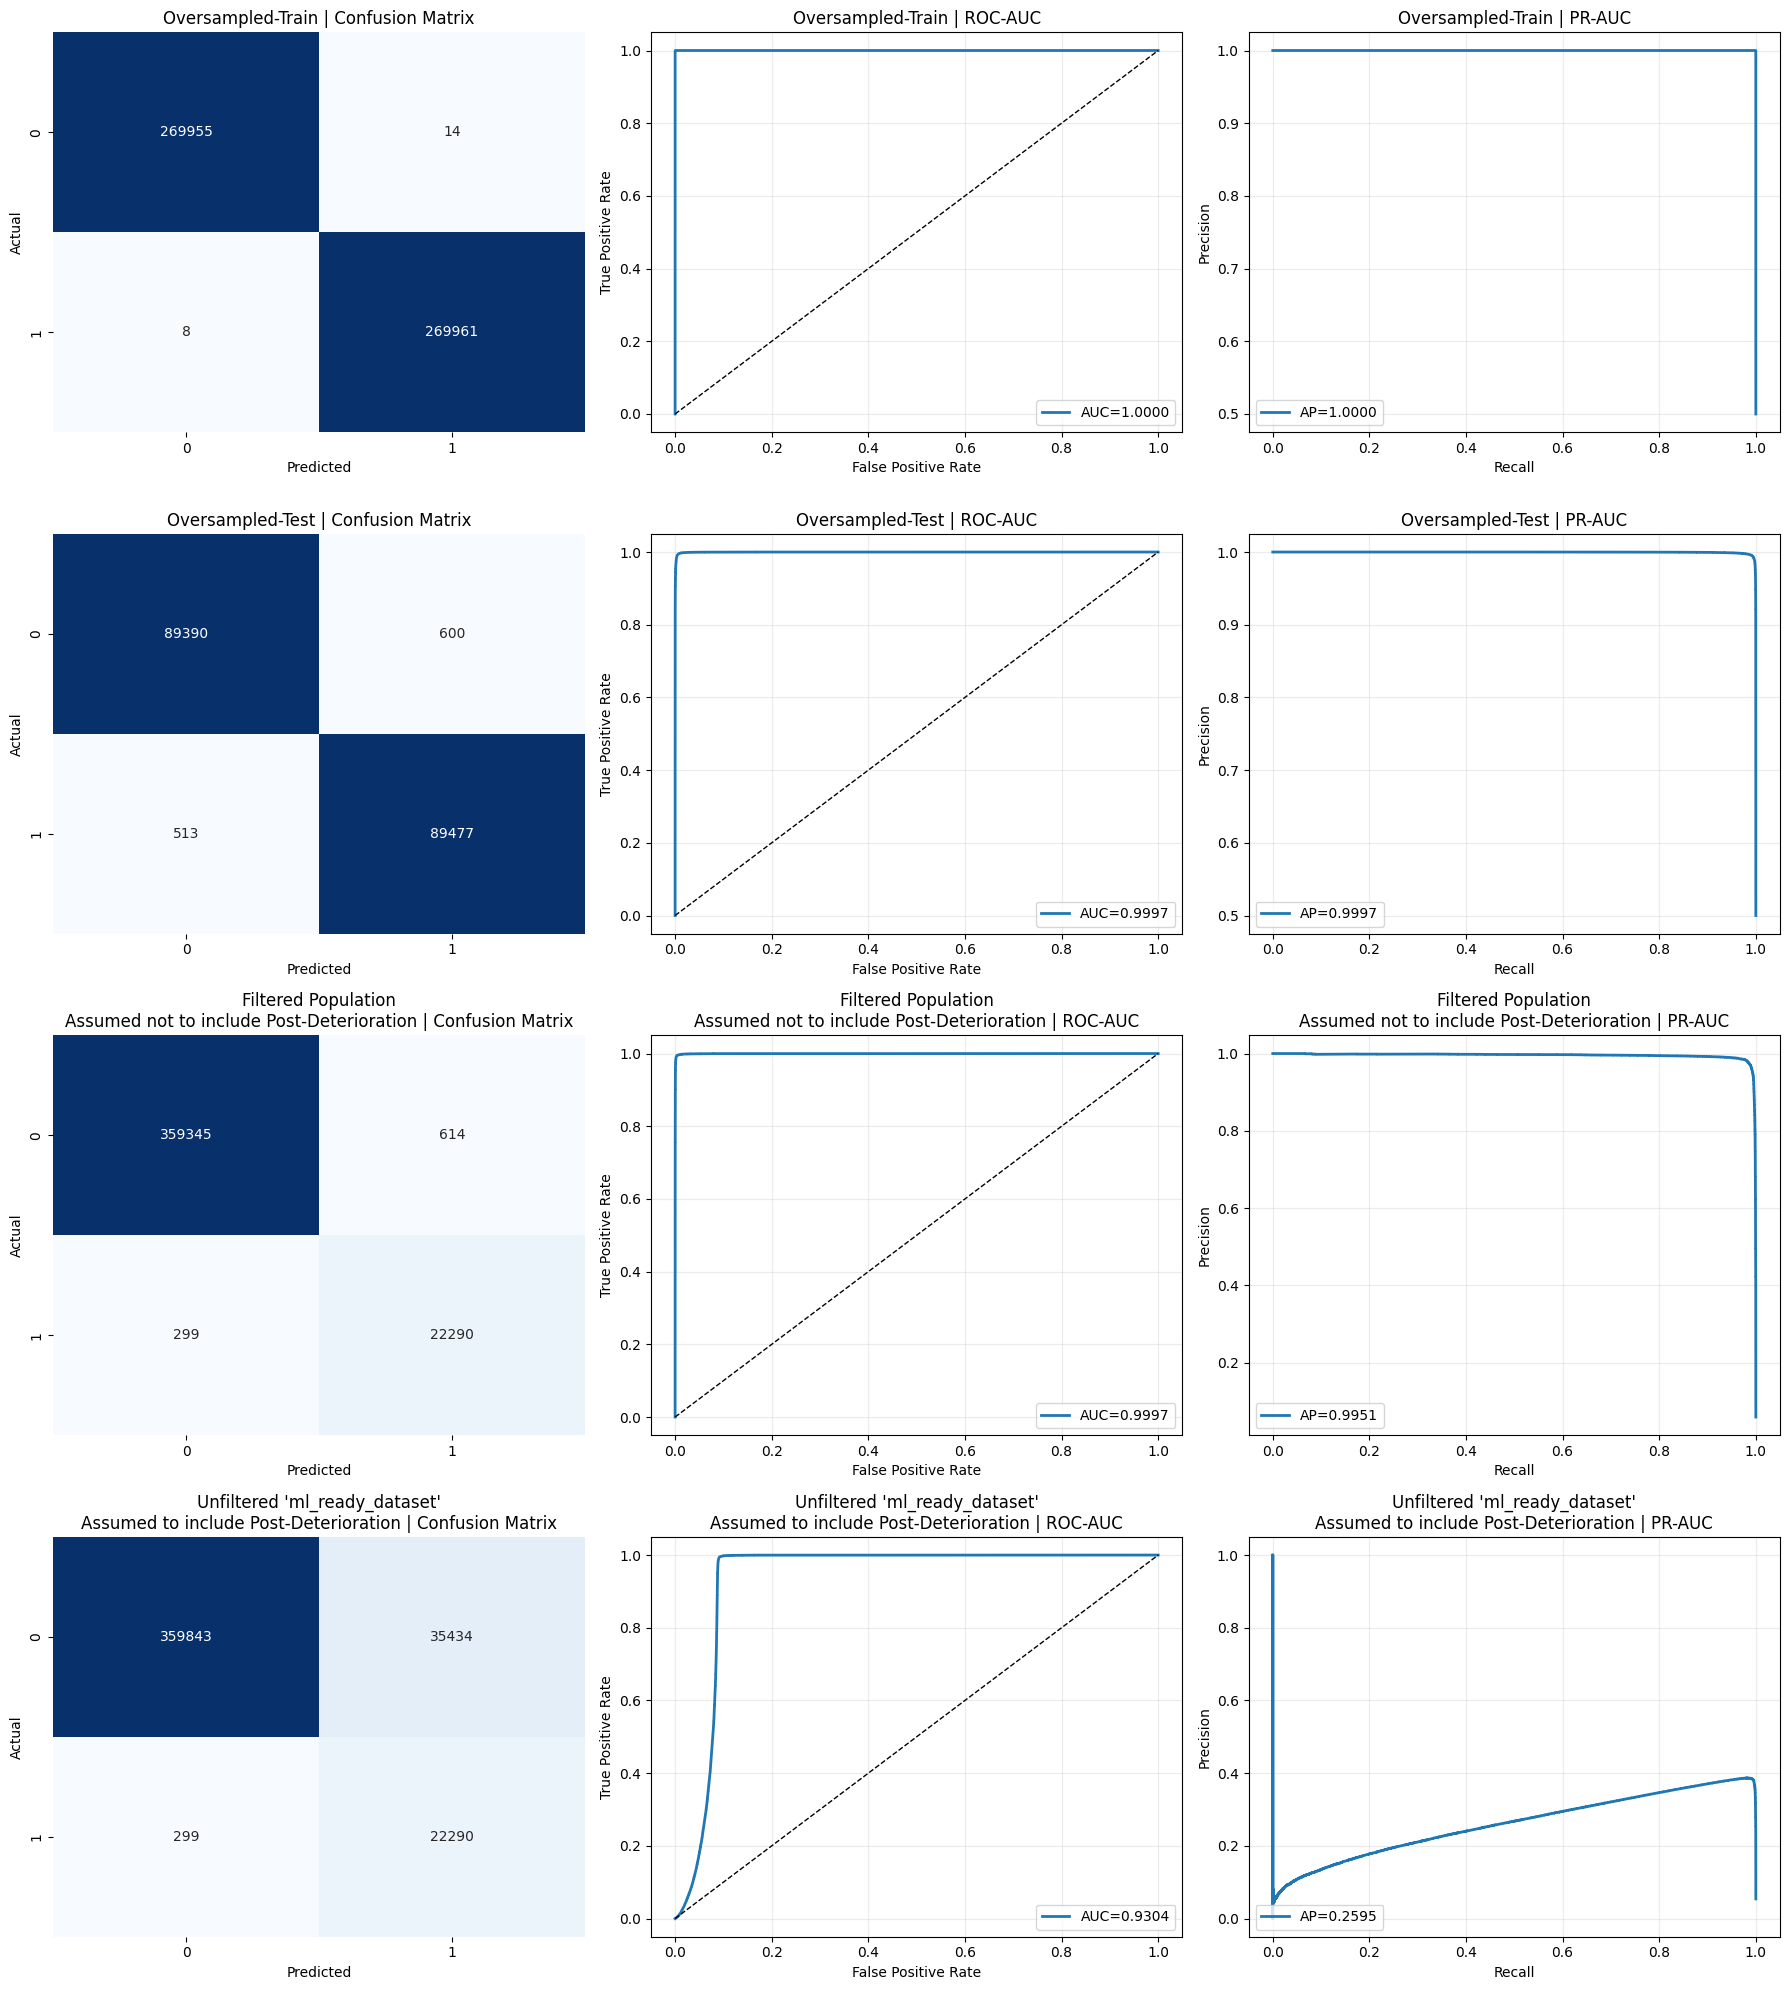

In [18]:
make_plots(model=model,
               X_vals=[X_train_raw, X_test_raw, X_population, X_post_deterioration ],
               y_values=[y_train_raw, y_test, y_population, y_post_deterioration ],
               data_lables=['Oversampled-Train', 'Oversampled-Test', 'Filtered Population\nAssumed not to include Post-Deterioration', "Unfiltered 'ml_ready_dataset'\nAssumed to include Post-Deterioration"])

# Stakeholder Presentation  
### Turn it in to a forecast problem by dropping post deterioration observations   
An assumption was made based on the data that was not labeled ML ready.  
Assumption: it is the same data, but in a different state  
## Use Bayes Theorem to Frame Predictions  

In [19]:
from sklearn.metrics import confusion_matrix
def confusion_matrix_to_bayes_theorem_probas(confusion_matrix_):
    """
    where probabilty (p), hypothosis (h), evidence (e)
    p(h|e) = p(e|h) * p(h) / p(e)

    returns p(h|e) , p(e|h)
    where the denominator is p(h)*p(e|h) + p(not h)*p(e|not h)
    p(e|h) is determined by counts, not multiplying p(h)*p(e)/p(e)

    returns returns p(true|pred) , p(pred|true) 
    both as diagonal of matrix from top-left to lower-right
    """
    if hasattr(confusion_matrix_,'toarray'):
        matrix = confusion_matrix_.toarray()
    else:
        matrix = np.array(confusion_matrix_)


    #prior
    sum_observations = matrix.sum(axis=1)    
    p_h     = sum_observations / sum_observations.sum()
    p_not_h = 1 - p_h

    #new evidence
    sum_predictions  = matrix.sum(axis=0)

    sum_population   = matrix.sum(axis=-1).sum()


    p_e_given_h = []
    p_e_given_not_h = []
    for e_location in range(len(sum_observations)):
        n_true_e        = matrix[e_location][e_location]
        n_h             = sum_observations[e_location] 
        n_not_h         = sum_observations.sum() - sum_observations[e_location]
        n_e_given_not_h = sum_predictions[e_location] - matrix[e_location][e_location]
        if n_h==0:
            pegh   = 0
        else:
            pegh   = n_true_e / n_h
        p_e_given_h.append(pegh)
        if n_not_h==0:
            pegnh = 0
        else:
            pegnh = n_e_given_not_h / n_not_h
        p_e_given_not_h.append(pegnh)
    p_e_given_h = np.array(p_e_given_h)
    p_e_given_not_h = np.array(p_e_given_not_h)
    try:
        p_observed     = p_h * p_e_given_h
        p_not_observed = p_not_h * p_e_given_not_h
        p_h_given_e  = p_observed / (p_observed + p_not_observed)

    except:
        logph, logpeh, logpnh, logpenh = np.log(p_h) , np.log(p_e_given_h) , np.log(p_not_h) , np.log(p_e_given_not_h) 

        log_obs, log_un_observed  =  (logph+logpeh) , (logpnh+logpenh)

        m               = np.maximum(log_obs, log_un_observed)

        log_denominator = m + np.log( np.exp(log_obs - m) + np.exp(log_un_observed - m) )

        p_h_given_e     = np.exp(log_obs - log_denominator)

    return p_h_given_e, p_e_given_h

matrix = confusion_matrix(y_population,model.predict(X_population))

p_h_given_e, p_e_given_h = confusion_matrix_to_bayes_theorem_probas(matrix)
p_h_given_e, p_e_given_h = p_h_given_e.round(3), p_e_given_h.round(3)
print(f"        P(det | pred det) = {p_h_given_e[1]}   |   Probability that deterioration WILL occur within the next 12 hours given that deterioration IS predicted within the next 12 hours.")
print(f"P(non det | pred non det) = {p_h_given_e[0]}   |   Probability that deterioration WILL NOT occur within the next 12 hours given that NON deterioration IS predicted within the next 12 hours.")
print(f"P(pred non det | non det) = {p_e_given_h[0]}   |   Probability that A NON deterioration WILL BE PREDICTED AS NON DETERIORATION given that deterioration WILL NOT HAPPEN within the next 12 hours.")
print(f"        P(pred det | det) = {p_e_given_h[1]}   |   Probability that A deterioration WILL BE PREDICTED AS A DETERIORATION given that deterioration WILL HAPPEN within the next 12 hours.")


        P(det | pred det) = 0.973   |   Probability that deterioration WILL occur within the next 12 hours given that deterioration IS predicted within the next 12 hours.
P(non det | pred non det) = 0.999   |   Probability that deterioration WILL NOT occur within the next 12 hours given that NON deterioration IS predicted within the next 12 hours.
P(pred non det | non det) = 0.998   |   Probability that A NON deterioration WILL BE PREDICTED AS NON DETERIORATION given that deterioration WILL NOT HAPPEN within the next 12 hours.
        P(pred det | det) = 0.987   |   Probability that A deterioration WILL BE PREDICTED AS A DETERIORATION given that deterioration WILL HAPPEN within the next 12 hours.


In [ ]:
'''
import joblib
joblib.dump(model,'BEST_HCD_XGBOOST.joblib')
#joblib.dump(numeric_transformer,'BEST_HCD_XGB_NUM_TRANSFORMER.joblib')
joblib.dump(categorical_encoder, 'BEST_HCD_XGB_CAT_ENCODER.joblib')
'''

['BEST_HCD_XGB_CAT_ENCODER.joblib']